In [ ]:
import pandas as pd
import numpy as np

df_open = pd.read_csv('/content/csi_open.csv')
df_close = pd.read_csv('/content/csi_close.csv')
df_person = pd.read_csv('/content/csi_person.csv')

feature_cols = [f'SC_{i}' for i in range(4, 60) if i != 32]
df_open = df_open[feature_cols].copy()
df_close = df_close[feature_cols].copy()
df_person = df_person[feature_cols].copy()
df_open['label'] = 0
df_close['label'] = 1
df_person['label'] = 2
df_combined = pd.concat([df_open, df_close, df_person], axis=0, ignore_index=True)

# Display summary info to verify
print(f'Combined DataFrame shape: {df_combined.shape}')
print(df_combined.head())
print('\nLabel distribution:')
print(df_combined['label'].value_counts())

Combined DataFrame shape: (600, 56)
   SC_4  SC_5  SC_6  SC_7  SC_8  SC_9  SC_10  SC_11  SC_12  SC_13  ...  SC_51  \
0   255   255   250   217   151   131    102     86     80     82  ...    139   
1   177   166   176   168   190   190    222    198    176    156  ...     88   
2   159   145   160   178   178   178    182    182    165    151  ...     89   
3   255   255   246   222   167   136    100     78     68     65  ...    148   
4   255   255   255   237   185   139    101     84     72     81  ...    145   

   SC_52  SC_53  SC_54  SC_55  SC_56  SC_57  SC_58  SC_59  label  
0    139    111    102     89    102     99    118    164      0  
1    111    147    177    204    220    220    220    238      0  
2    127    159    188    198    210    223    223    244      0  
3    148    131    131    130    145    131    148    167      0  
4    118    118    109    125    118    129    163    185      0  

[5 rows x 56 columns]

Label distribution:
label
0    200
1    200
2    20

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df_combined[feature_cols].values
y = df_combined['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (480, 55)
Testing set shape: (120, 55)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(55,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting model training...")
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

model.summary()

Starting model training...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2410 - loss: 1.1873 - val_accuracy: 0.3958 - val_loss: 1.0575
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4952 - loss: 1.0434 - val_accuracy: 0.6771 - val_loss: 0.9719
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6134 - loss: 0.9701 - val_accuracy: 0.6771 - val_loss: 0.8658
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6805 - loss: 0.8588 - val_accuracy: 0.7396 - val_loss: 0.7563
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7335 - loss: 0.7613 - val_accuracy: 0.8854 - val_loss: 0.6374
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8365 - loss: 0.6316 - val_accuracy: 0.9062 - val_loss: 0.5300
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8835 - loss: 0.5061 - val_accuracy: 0.9479 - val_loss: 0.4300
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8992 - loss: 0.4524 - val_accuracy: 0.9271 - val_loss: 0.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,291 (67.55 KB)

 Trainable params: 5,763 (22.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,528 (45.04 KB)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Confusion Matrix:
[[40  0  0]
 [ 0 40  0]
 [ 0  0 40]]

Classification Report:
              precision    recall  f1-score   support

        open       1.00      1.00      1.00        40
       close       1.00      1.00      1.00        40
      person       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



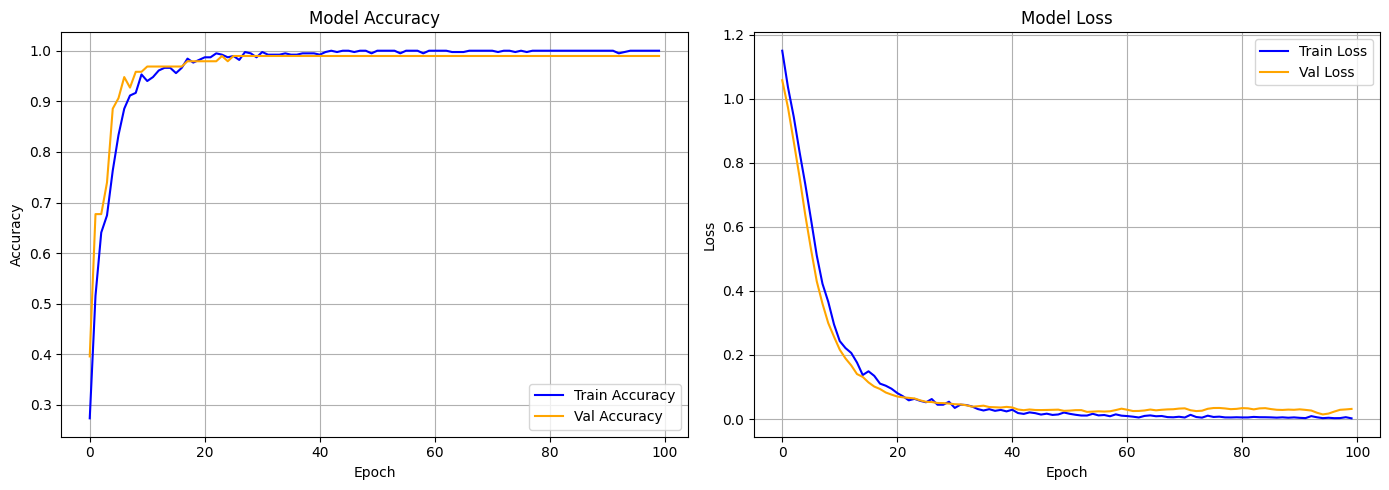

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Predict classes for X_test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Print evaluation metrics
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['open', 'close', 'person']))

# 3. Visualize training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_file_path = '/content/model.tflite'
with open(tflite_file_path, 'wb') as f:
    f.write(tflite_model)

# Verify the file exists
if os.path.exists(tflite_file_path):
    print(f'Success: Model successfully converted and saved to {tflite_file_path}')
    print(f'File size: {os.path.getsize(tflite_file_path)} bytes')
else:
    print('Error: Failed to save the TFLite model.')

Saved artifact at '/tmp/tmpe9badyju'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 55), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137504352859152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352862032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352860880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352861840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352859920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504037667856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Success: Model successfully converted and saved to /content/model.tflite
File size: 25172 bytes


In [ ]:
def predict_csi_state(new_df, model, scaler, feature_cols):
    X_new_raw = new_df[feature_cols].values
    X_new_scaled = scaler.transform(X_new_raw)
    predictions_probs = model.predict(X_new_scaled, verbose=0)
    predicted_classes = np.argmax(predictions_probs, axis=1)

    class_map = {0: 'open', 1: 'close', 2: 'person'}
    predicted_labels = [class_map[c] for c in predicted_classes]
    return np.array(predicted_labels)

def predict_from_csv(file_path, model, scaler, feature_cols, aggregate=False, window_size=15):
    # 1. Load data
    new_data = pd.read_csv(file_path)

    # 2. Get raw predictions using the previous helper
    raw_predictions = predict_csi_state(new_data, model, scaler, feature_cols)

    if not aggregate:
        return raw_predictions

    # 3. Aggregation logic
    aggregated_results = []
    for i in range(0, len(raw_predictions), window_size):
        window = raw_predictions[i : i + window_size]
        if len(window) > 0:
            # Use np.unique to find the most frequent string label
            values, counts = np.unique(window, return_counts=True)
            majority_label = values[np.argmax(counts)]
            aggregated_results.append(majority_label)

    return np.array(aggregated_results)

In [ ]:
import os
test_csv_path = '/content/test.csv'

if os.path.exists(test_csv_path):
    aggregation = True
    rows = 10

    final_results = predict_from_csv(
        file_path=test_csv_path,
        model=model,
        scaler=scaler,
        feature_cols=feature_cols,
        aggregate=aggregation,
        window_size=rows
    )
    print(final_results)
else:
    print(f'File not found.')

['person' 'person' 'person' 'person' 'open' 'person' 'person' 'person'
 'person' 'person' 'person' 'person' 'person' 'person' 'person' 'person'
 'person' 'person' 'person' 'person']
